# **SUICIDE RATE ANALYSIS AND PREDICTIVE MODELING**

# **Project Overview**

This project analyzes global suicide statistics from 1985–2016 to identify demographic and socioeconomic factors influencing suicide rates. The workflow includes data cleaning, exploratory data analysis (EDA), feature engineering, and predictive modeling.

# **Objectives**


* Predict suicide risk category using demographic and socioeconomic features.
* Compare multiple machine learning classification models.
* Evaluate model performance using standard classification metrics.
* Identify the most influential features affecting predictions.










# **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from xgboost import XGBRegressor

from sklearn.inspection import permutation_importance

# **2. Load Dataset**

In [2]:
df = pd.read_csv("data/master.csv")

df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


# **3. Dataset Information**

In [3]:
# Check dataset structure, data types and number of non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


In [4]:
df.describe()

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
count,27820.000000,27820.000000,2.782000e+04,27820.000000,8364.000000,27820.000000
mean,2001.258375,242.574407,1.844794e+06,12.816097,0.776601,16866.464414
std,8.469055,902.047917,3.911779e+06,18.961511,0.093367,18887.576472
min,1985.000000,0.000000,2.780000e+02,0.000000,0.483000,251.000000
25%,1995.000000,3.000000,9.749850e+04,0.920000,0.713000,3447.000000
50%,2002.000000,25.000000,4.301500e+05,5.990000,0.779000,9372.000000
75%,2008.000000,131.000000,1.486143e+06,16.620000,0.855000,24874.000000
max,2016.000000,22338.000000,4.380521e+07,224.970000,0.944000,126352.000000


In [5]:
df.shape

(27820, 12)

In [6]:
df.columns

Index(['country', 'year', 'sex', 'age', 'suicides_no', 'population',
       'suicides/100k pop', 'country-year', 'HDI for year',
       ' gdp_for_year ($) ', 'gdp_per_capita ($)', 'generation'],
      dtype='object')

## **4. Missing Value Analysis**

In [7]:
df.isnull().sum()

,0
country,0
year,0
sex,0
age,0
suicides_no,0
population,0
suicides/100k pop,0
country-year,0
HDI for year,19456
gdp_for_year ($),0


# **5. Correlation Heatmap**

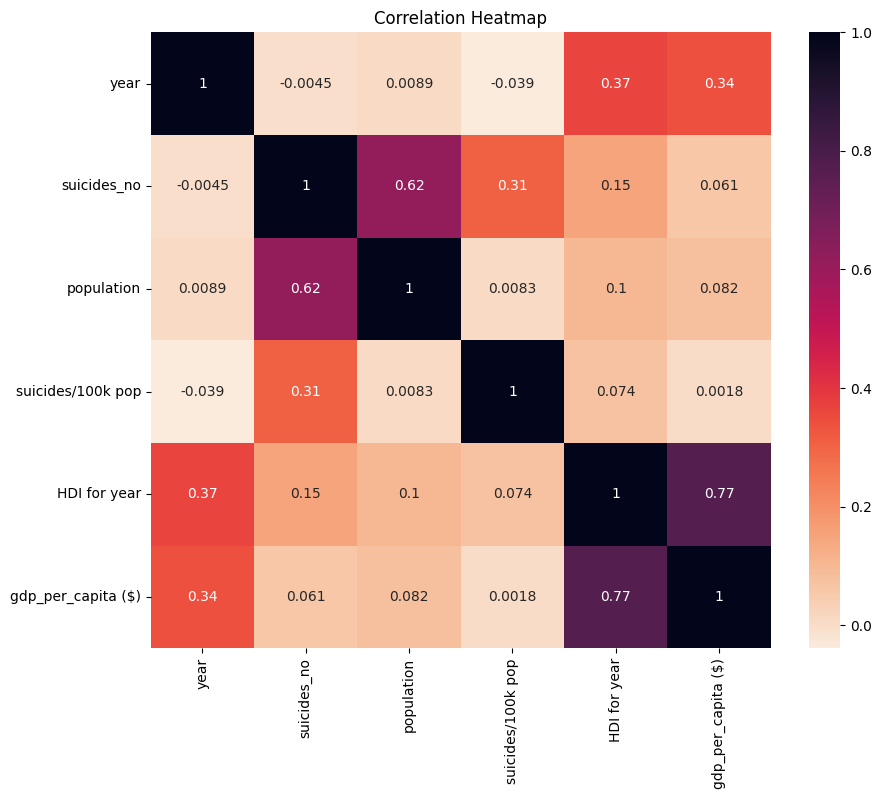

In [8]:
# Visualize correlation between numerical variables

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap= 'rocket_r')

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Some variables show relationships with each other.
For example, suicides_no is strongly related to population, which is expected because countries with larger populations may have more suicide cases.

# **6. Data Cleaning**

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df = df.drop("HDI for year", axis=1)

df = df.drop("country-year", axis=1)

In [11]:
df.rename({'sex':'gender', 'suicides/100k pop':'suicide_rate', 'gdp_for_year ($)':'gdp_per_year', 'gdp_per_capita ($)':'gdp_per_capita'}, axis=1, inplace=True)

In [12]:
df.columns

Index(['country', 'year', 'gender', 'age', 'suicides_no', 'population',
       'suicide_rate', 'gdp_per_year', 'gdp_per_capita', 'generation'],
      dtype='object')

## Boxplot

<Axes: xlabel='suicide_rate'>

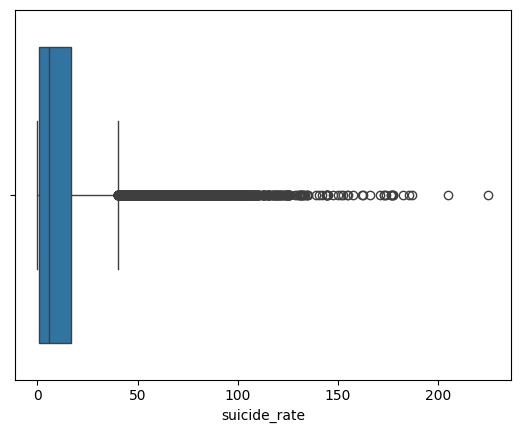

In [13]:
sns.boxplot(x=df["suicide_rate"])

The boxplot shows several high values in suicide rates, indicating the presence of outliers. These values were retained because, they likely represent real-world variations across countries and years.

# **7. Exploratory Data Analysis (EDA)**

### Distribution of Suicide Rate

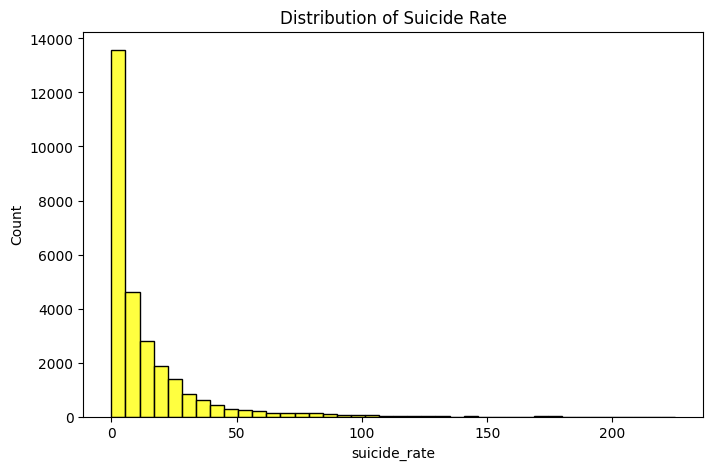

In [14]:
# Plot the distribution of suicide rate to understand its spread and skewness

plt.figure(figsize=(8,5))
sns.histplot(df["suicide_rate"], bins=40, color= 'yellow')

plt.title("Distribution of Suicide Rate")
plt.show()

Most suicide rates are concentrated at lower values, with fewer observations at higher values.
This indicates the data is slightly right-skewed.

### Suicide Rate Trend Over Years

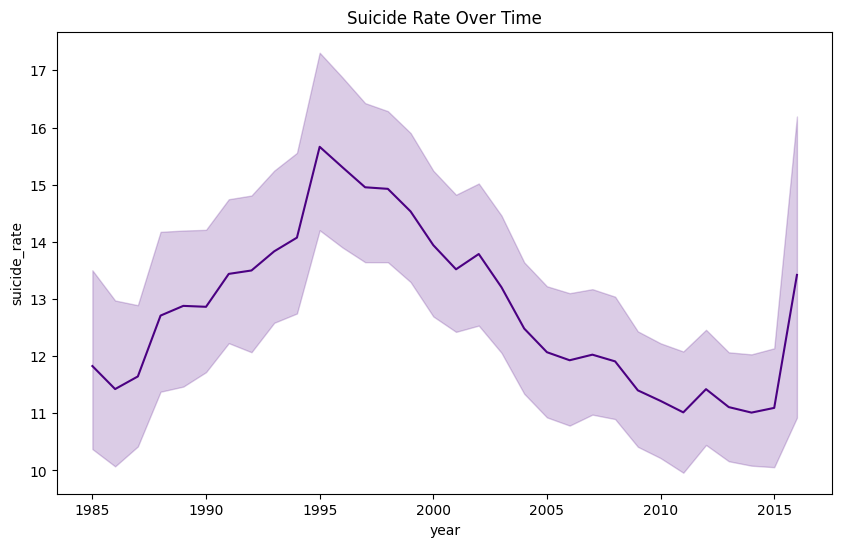

In [15]:
# Visualize how suicide rate changes over the years

plt.figure(figsize=(10,6))
sns.lineplot(x="year", y="suicide_rate", data=df, color= 'indigo')

plt.title("Suicide Rate Over Time")
plt.show()

The suicide rate changes gradually across the years.
Some fluctuations can be observed over time.

### Suicide Rate by Gender

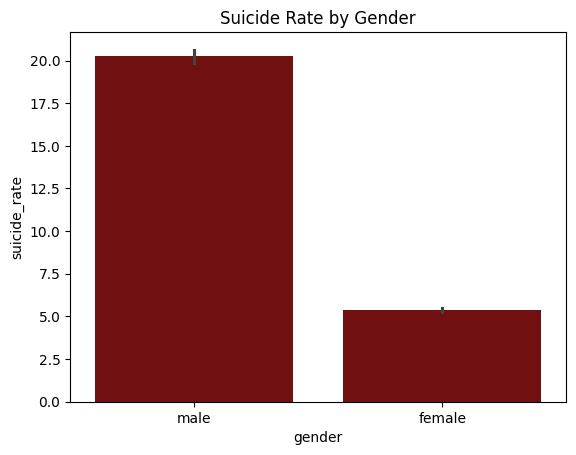

In [16]:
# Compare suicide rate between genders

sns.barplot(x="gender", y="suicide_rate", data=df, color= 'maroon')

plt.title("Suicide Rate by Gender")
plt.show()

The chart shows that males generally have a higher suicide rate than females in the dataset.

### Suicide Rate by Generation

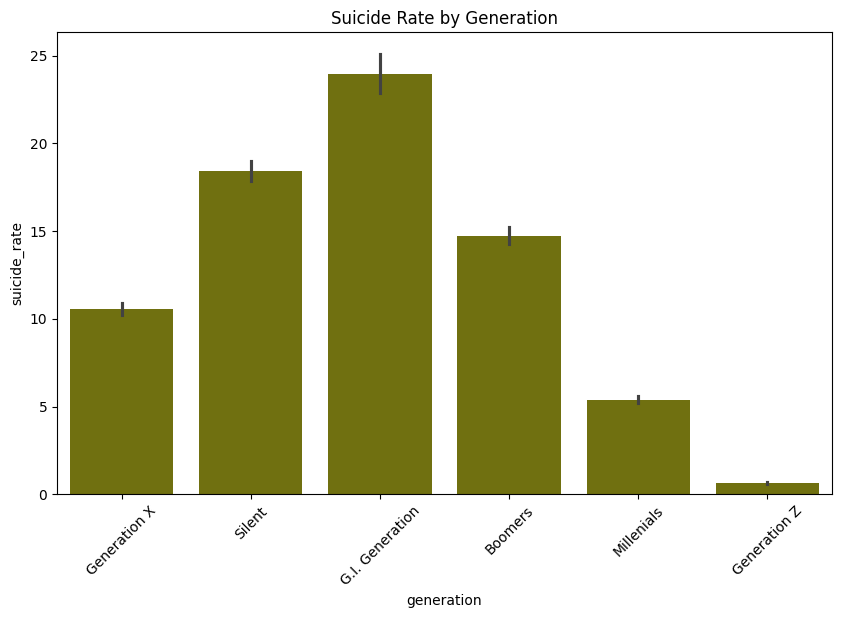

In [17]:
# Compare suicide rate among different generations

plt.figure(figsize=(10,6))

sns.barplot(x="generation", y="suicide_rate", data=df, color= 'olive')

plt.xticks(rotation=45)

plt.title("Suicide Rate by Generation")
plt.show()

Different generations show different average suicide rates.
This suggests that age group and generation may influence suicide patterns.

### Suicide Count by Age Group

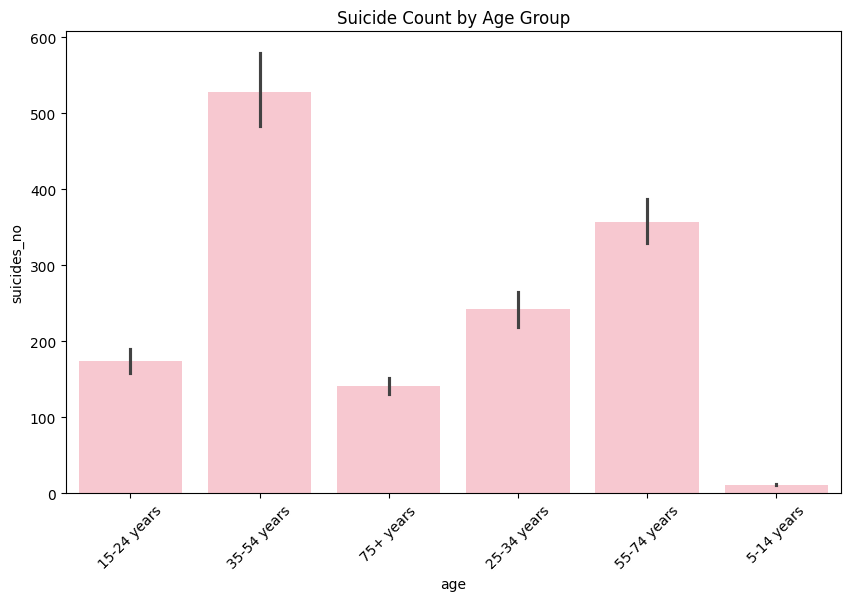

In [18]:
# Analyze total suicide counts across age groups

plt.figure(figsize=(10,6))

sns.barplot(x="age", y="suicides_no", data=df, color= 'pink')

plt.xticks(rotation=45)

plt.title("Suicide Count by Age Group")
plt.show()

Suicide counts vary across age groups.
Some middle and older age groups show higher counts compared to younger groups.

### Top Countries with Highest Suicide Count

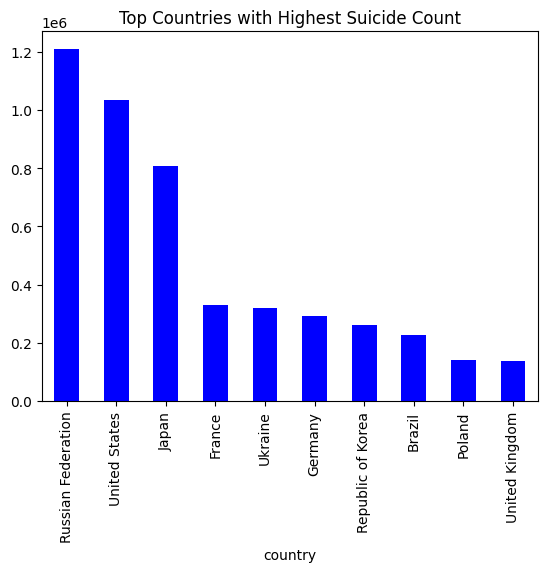

In [19]:
# Identify countries with the highest total suicide counts

top_countries = df.groupby("country")["suicides_no"].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar", color= 'blue')

plt.title("Top Countries with Highest Suicide Count")
plt.show()

Some countries show higher total suicide counts.
However, this may also be influenced by larger population sizes.

# **8. Feature Engineering**

In [20]:
# Remove suicides_no to avoid redundancy since suicide_rate is the prediction target

df = df.drop("suicides_no", axis=1)

In [21]:
print(df.dtypes)

country            object
year                int64
gender             object
age                object
population          int64
suicide_rate      float64
gdp_per_year       object
gdp_per_capita      int64
generation         object
dtype: object


In [22]:
# Convert GDP values from string format with commas to numerical format

df["gdp_per_year"] = df["gdp_per_year"].str.replace(",", "", regex=False).astype(float)

# **9. Encode Categorical Variables**

In [23]:
# Convert categorical variables into numerical form using Label Encoding

le = LabelEncoder()

categorical_columns = ["country","gender","age","generation"]

for col in categorical_columns:

    df[col] = le.fit_transform(df[col])

# **10. Feature Scaling**

In [24]:
# Scale numerical features to reduce the effect of extreme values

scaler = RobustScaler()

scale_cols = ["population","gdp_per_year","gdp_per_capita"]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

# **11. Define Features and Target**

In [25]:
X = df.drop("suicide_rate", axis=1)

y = df["suicide_rate"]

# **12. Train-Test Split**

In [26]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

# **13. Model Training**

In [27]:
# Define multiple regression models for comparison

models = {

"Linear Regression": LinearRegression(),

"Decision Tree": DecisionTreeRegressor(random_state=42),

"Random Forest": RandomForestRegressor(random_state=42),

"Gradient Boosting": GradientBoostingRegressor(random_state=42),

"AdaBoost": AdaBoostRegressor(random_state=42),

"Bagging": BaggingRegressor(random_state=42),

"XGBoost": XGBRegressor(random_state=42)
}

# **14. Model Evaluation**

In [28]:
# Train models and evaluate them using R² score and RMSE

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, rmse])

# **15. Model Comparison**

In [29]:
results_df = pd.DataFrame(

    results,

    columns=["Model","R2 Score","RMSE"]
)

In [30]:
results_df.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,RMSE
2,Random Forest,0.872558,6.673506
6,XGBoost,0.866682,6.825633
5,Bagging,0.854041,7.141895
1,Decision Tree,0.808617,8.178047
3,Gradient Boosting,0.571480,12.237247
0,Linear Regression,0.199717,16.723225
4,AdaBoost,0.177096,16.957925


The comparison shows that ensemble models such as Random Forest, XGBoost, and Bagging perform better than simpler models in predicting suicide rates.

# **16. Model Performance Visualization**

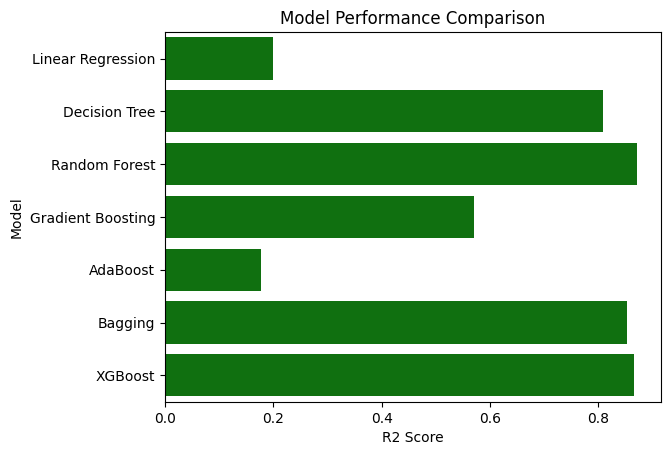

In [31]:
# Visual comparison of model performance

sns.barplot(x="R2 Score", y="Model", data=results_df, color= 'green')

plt.title("Model Performance Comparison")

plt.savefig("images/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# **17. Feature Importance (Random Forest)**

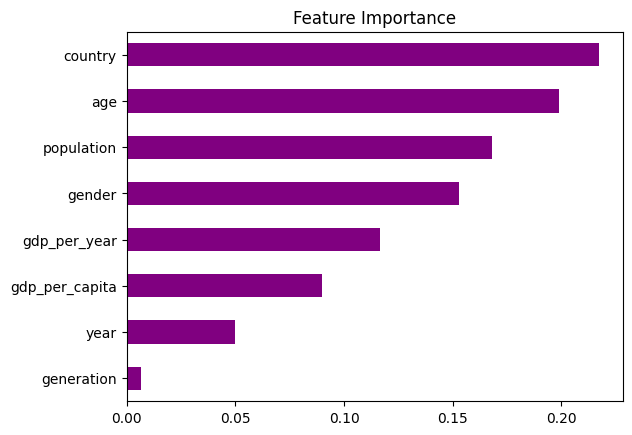

In [32]:
# Train Random Forest model to identify important features

rf= RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

importance = rf.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values().plot(kind="barh", color= 'purple')

plt.title("Feature Importance")

plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

The plot shows which features are most important for predicting suicide rate.
Variables like age, population, and economic indicators contribute more to the model.

# **18. Permutation Feature Importance**

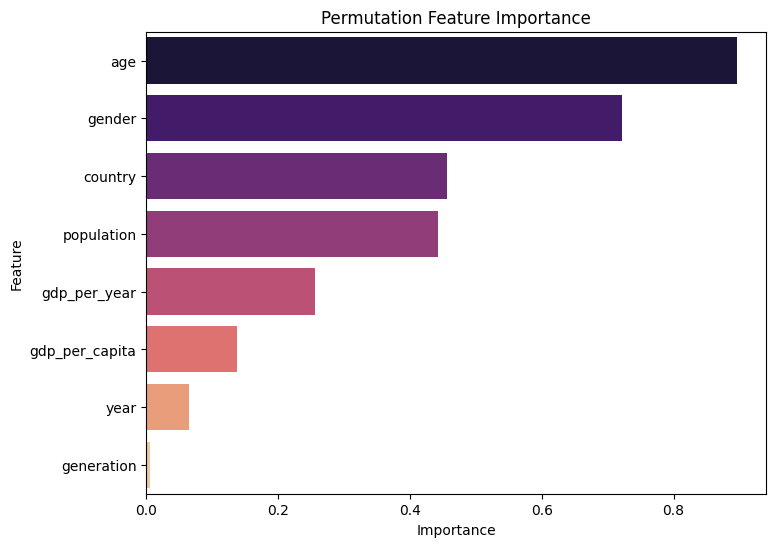

In [33]:
# Measure feature importance by shuffling feature values and observing performance drop

perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=perm_df,
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Permutation Feature Importance")

plt.savefig("images/permutation_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

Permutation importance confirms which variables affect the model most.
Features that cause a larger drop in performance when shuffled are considered more important.

# **Conclusion**

This project analyzed global suicide trends using demographic and socioeconomic variables and developed multiple machine learning models to predict suicide rates.

The workflow included data cleaning, exploratory data analysis (EDA), feature engineering, data preprocessing, model training, performance evaluation, and feature importance analysis.

Among the evaluated models, ensemble methods such as Random Forest, XGBoost, and Bagging achieved better predictive performance than simpler regression models, while AdaBoost performed comparatively lower on this dataset.

The analysis also identified age group, gender, and economic indicators as some of the most influential factors affecting suicide rates.

Overall, this project demonstrates practical skills in Python, pandas, NumPy, scikit-learn, data preprocessing, exploratory data analysis, feature engineering, machine learning model development, model evaluation, and data visualization.

# **Future Improvements**

- Perform hyperparameter tuning to further improve model performance.
- Experiment with additional machine learning algorithms for comparison.
- Incorporate more recent and comprehensive suicide datasets to enhance model generalizability.
- Explore advanced feature engineering techniques to improve predictive accuracy.
- Develop an interactive dashboard or web application to visualize predictions and insights.